In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load Raw Data    
df = pd.read_csv("retrospective_raw_data.csv")

countries_keep = ["Brunei", "Cambodia", "Indonesia", "Laos", "Malaysia", "Myanmar", "Philippines", "Singapore", "Thailand", "Timor-Leste", "Vietnam"]
df = df[df["Countries"].isin(countries_keep)]
df.head()

,Commodities,Countries,DomesticForeign,District,Time,Value ($US) (Default Member)
195,2504 Natural Graphite,Indonesia,Foreign Exports,All Districts,2012,5852
196,2504 Natural Graphite,Indonesia,Foreign Exports,All Districts,August 2012,5852
222,2504 Natural Graphite,Malaysia,Foreign Exports,All Districts,2025,49650
223,2504 Natural Graphite,Malaysia,Foreign Exports,All Districts,November 2025,49650
224,2504 Natural Graphite,Singapore,Foreign Exports,All Districts,2012,2800


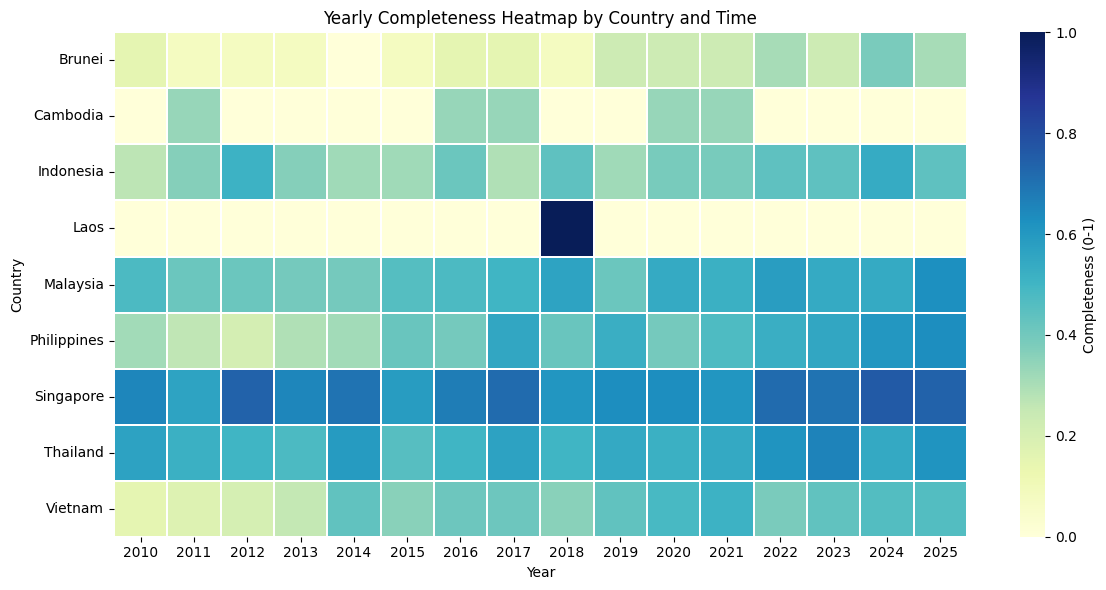

In [21]:
# Data Completeness Check
country_col = "Countries" if "Countries" in df.columns else None
commodity_col = "Commodities" if "Commodities" in df.columns else None
if country_col is None or commodity_col is None:
    raise ValueError("Missing Countries or Commodities column. Please check the raw data schema.")

# filter yearly data
yearly = df[df["Time"].astype(str).str.fullmatch(r"\d{4}", na=False)].copy()
yearly["year"] = pd.to_numeric(yearly["Time"], errors="coerce").astype("Int64")
yearly_plot = yearly.dropna(subset=["year"]).copy()
yearly_plot["year"] = yearly_plot["year"].astype(int)

# observed commodities per country-year
observed = yearly_plot.groupby([country_col, "year"])[commodity_col].nunique()

# total number of commodities per country over all years
total = yearly_plot.groupby(country_col)[commodity_col].nunique()

completeness = observed.div(total, level=0).rename("completeness")

# matrix for heatmap
yearly_pivot = (
    completeness.reset_index()
    .pivot(index=country_col, columns="year", values="completeness")
    .fillna(0)
    .sort_index()
    .sort_index(axis=1)
)

n_rows, n_cols = yearly_pivot.shape
fig_w = max(12, min(36, n_cols * 0.28))
fig_h = max(6, min(30, n_rows * 0.35))

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    yearly_pivot,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Completeness (0-1)"}
 )
plt.title("Yearly Completeness Heatmap by Country and Time")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [22]:
# Data Preprocessing
df = df.drop(columns=['DomesticForeign', 'District'])
df['HS_Code'] = df['Commodities'].astype(str).str[:4]

years = df[df['Time'].astype(str).str.strip().str.len() == 4]
years = df['Time']

# Remove rows with only year because all monthly values add up to the yearly value anyway
df = df[df['Time'].astype(str).str.strip().str.len() != 4]

# Create Month column
temp = df['Time'].str.split()
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df['Month'] = temp.str[0].map(month_map)

# Create Year column
df['Year'] = temp.str[-1].astype(int)
df = df.drop(columns = ['Time'])

df = df.rename(columns={'Value ($US) (Default Member)': 'Nominal_Value'})

# Adjusting for Inflation
inflation_rates = pd.read_csv("inflation_rates.csv")
df = df.merge(inflation_rates, on="Year")

# Use annual inflation rates for all months (i.e. for all months in 2011, use the annual inflation rate for 2011 to calculate CPI)

df['CPI'] = np.nan
curr_cpi = 100
for year in range(2010, 2026):
    inf_rate_rows = df[df['Year'] == year]
    inf_rate = inf_rate_rows['Inflation_Rate'].iloc[0] / 100

    if (year == 2010):
        df.loc[df['Year'] == 2010, 'CPI'] = curr_cpi
    else:
        curr_cpi = curr_cpi * (inf_rate + 1)
        df.loc[df['Year'] == year, 'CPI'] = curr_cpi

# Quick check that all rows have a CPI value
print(df['CPI'].isna().sum())

# Convert nominal to real values
df['Real_Value'] = ((df['Nominal_Value'] / df['CPI']) * 100).round(3)

# Create Category Type column
def classify_commodity(commodity):
    if "Ore" in commodity or "Concentrates" in commodity:
        return "Ore/Raw"
    elif "Oxide" in commodity or "Compound" in commodity:
        return "Compound"
    elif "Article" in commodity or "And Articles" in commodity:
        return "Refined/Articles"
    elif "Battery" in commodity or "Magnet" in commodity:
        return "Advanced Product"
    else:
        return "Other"

df["CategoryType"] = df["Commodities"].apply(classify_commodity)

df.head()


0


,Commodities,Countries,Nominal_Value,HS_Code,Month,Year,Inflation_Rate,CPI,Real_Value,CategoryType
0,2504 Natural Graphite,Indonesia,5852,2504,8,2012,1.7,104.751000,5586.582,Other
1,2504 Natural Graphite,Malaysia,49650,2504,11,2025,2.7,148.078914,33529.419,Other
2,2504 Natural Graphite,Singapore,2800,2504,7,2012,1.7,104.751000,2673.006,Other
3,2504 Natural Graphite,Thailand,110900,2504,10,2020,1.4,118.919611,93256.276,Other
4,2504 Natural Graphite,Thailand,10269,2504,12,2020,1.4,118.919611,8635.245,Other
